In [93]:
import os
import cv2
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from typing import Tuple
from timm import create_model

## Set-up Dataset

In [94]:
_ = torchvision.datasets.Imagenette(
    root = './data',
    download=True
)

In [95]:
LABELS_MAP = {
    "n01440764": "fish",
    "n02102040": "dog",
    "n02979186": "speaker",
    "n03000684": "electric saw",
    "n03028079": "church",
    "n03394916": "trumpet",
    "n03417042": "truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute"
}

## Custom Image Folder

In [96]:
class ImageFolderDataset(Dataset):

  def __init__(
      self,
      root_dir: str,            # "./data/imagenette2"
      split: str = "train",
      labels_map: dict = LABELS_MAP,
      transform: callable = None
  ) -> None:

    self.split_dir = os.path.join(root_dir, split) # e.g. "./data/imagenette2/train"

    # mi serve perchè ad ogni label deve essere associato un numero
    # e.g. { "n01440764": 0, "n02102040": 1}
    label2target = {
        label: idx for idx, label in enumerate(labels_map.keys())
    }

    self.images = []
    self.targets = []
    self.labels = []
    for class_id in os.listdir(self.split_dir):
      class_dir_path = os.path.join(self.split_dir, class_id)
      images = os.listdir(class_dir_path)
      self.images += [
          os.path.join(class_dir_path, image) for image in images
      ]
      self.targets += [label2target[class_id]]*len(images)

      self.labels += [labels_map[class_id]]*len(images)

    self.transform = transform


  def __getitem__(self, index):

    image_path = self.images[index]
    image_target = self.targets[index]
    image_label = self.labels[index]

    image = Image.open(image_path).convert('RGB')
    if self.transform:
      image = self.transform(image)

    return image, image_target, image_path, image_label

  def __len__(self):
    return len(self.images)

In [97]:
# Training transform: resize + light augmentation + ImageNet normalization.
# (The plain ToTensor() version produced variable-size images that can't be batched.)
train_transform = T.Compose([
    T.ToTensor(),
    T.Resize((256, 256)),
    T.RandomCrop((224, 224)),
    T.RandomHorizontalFlip(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolderDataset(
    root_dir="./data/imagenette2",
    split="train",
    transform=train_transform,
)

In [98]:
transform = T.Compose(
    [
        T.ToTensor(),
        T.Resize((224, 224)),
        T.Normalize(mean=[.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ]
)

val_dataset = ImageFolderDataset(
    root_dir='data/imagenette2',
    split='val',
    transform=transform
)

## Model Setup

In [99]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: mps


In [100]:
model = create_model('resnet10t', pretrained=True, num_classes=10).to(device)

## Transfer Learning — Train a Custom Head

Quick transfer-learning training so Grad-CAM has a model actually adapted to the
10 Imagenette classes (sharper, more meaningful heatmaps than the raw pretrained net).

**Strategy**
- Freeze the pretrained `resnet10t` backbone; replace `model.fc` with a small trainable MLP head.
- Train **only** the head with Adam (`lr=1e-3`, `weight_decay=1e-4`), cross-entropy loss.
- `EarlyStopping` (patience 3, monitoring val loss) checkpoints the best model and reloads it.

Reusable pieces: `TrainingConfig` (dataclass), `EarlyStopping`, `freeze_backbone` /
`attach_classifier_head` helpers, and a `Trainer` class. The backbone and `model(x)`
stay intact, so the Grad-CAM section below works unchanged on the trained model.

In [101]:
from dataclasses import dataclass


@dataclass
class TrainingConfig:
    """Hyperparameters for head-only transfer learning on Imagenette (10 classes)."""
    num_classes: int = 10
    epochs: int = 15
    batch_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 1e-4
    head_hidden_dim: int = 256
    head_dropout: float = 0.4
    early_stopping_patience: int = 3
    checkpoint_path: str = "best_model.pt"
    num_workers: int = 0


class EarlyStopping:
    """Tracks a monitored metric and saves the best model; signals when to stop.

    Saving lives here so 'best checkpoint' and 'stop condition' stay in sync.
    """

    def __init__(self, patience: int = 3, mode: str = "min", checkpoint_path: str = "best_model.pt") -> None:
        assert mode in {"min", "max"}
        self.patience = patience
        self.mode = mode
        self.checkpoint_path = checkpoint_path
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def _is_improvement(self, score: float) -> bool:
        if self.best_score is None:
            return True
        return score < self.best_score if self.mode == "min" else score > self.best_score

    def step(self, score: float, model: nn.Module) -> bool:
        """Returns True if `score` improved (and the model was checkpointed)."""
        if self._is_improvement(score):
            self.best_score = score
            self.counter = 0
            torch.save(model.state_dict(), self.checkpoint_path)
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


def freeze_backbone(model: nn.Module) -> None:
    """Freeze every parameter so only a later-attached head will train."""
    for param in model.parameters():
        param.requires_grad = False


def attach_classifier_head(
    model: nn.Module,
    num_classes: int,
    hidden_dim: int = 256,
    dropout: float = 0.4,
) -> nn.Module:
    """Replace the timm classifier (`model.fc`) with a small trainable MLP head.

    The backbone (incl. layer4, used by Grad-CAM) and `model(x)` -> logits stay intact.
    """
    in_features = model.get_classifier().in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, hidden_dim),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(hidden_dim, num_classes),
    )
    return model

In [102]:
class Trainer:
    """Minimal, reusable training loop for image classification.

    Optimizes only the parameters with requires_grad=True (i.e. the custom head),
    tracks history, and delegates best-model checkpointing to EarlyStopping.
    """

    def __init__(self, model: nn.Module, config: TrainingConfig, device: torch.device) -> None:
        self.model = model
        self.config = config
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.lr,
            weight_decay=config.weight_decay,
        )
        self.early_stopping = EarlyStopping(
            patience=config.early_stopping_patience,
            mode="min",
            checkpoint_path=config.checkpoint_path,
        )
        self.history = {"train_loss": [], "val_loss": [], "val_acc": []}

    def _run_epoch(self, loader: DataLoader, train: bool) -> Tuple[float, float]:
        self.model.train() if train else self.model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.set_grad_enabled(train):
            # ImageFolderDataset yields (image, target, path, label); we only need the first two.
            for images, targets, *_ in loader:
                images = images.to(self.device)
                targets = targets.to(self.device)

                if train:
                    self.optimizer.zero_grad()

                logits = self.model(images)
                loss = self.criterion(logits, targets)

                if train:
                    loss.backward()
                    self.optimizer.step()

                running_loss += loss.item() * images.size(0)
                correct += (logits.argmax(dim=1) == targets).sum().item()
                total += images.size(0)

        return running_loss / total, correct / total

    def fit(self, train_loader: DataLoader, val_loader: DataLoader) -> dict:
        for epoch in range(1, self.config.epochs + 1):
            train_loss, train_acc = self._run_epoch(train_loader, train=True)
            val_loss, val_acc = self._run_epoch(val_loader, train=False)

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)

            improved = self.early_stopping.step(val_loss, self.model)
            marker = "  <- best (saved)" if improved else ""
            print(
                f"Epoch {epoch:02d}/{self.config.epochs} | "
                f"train_loss {train_loss:.4f} acc {train_acc:.3f} | "
                f"val_loss {val_loss:.4f} acc {val_acc:.3f}{marker}"
            )

            if self.early_stopping.should_stop:
                print(
                    f"Early stopping: no val_loss improvement for "
                    f"{self.config.early_stopping_patience} epochs."
                )
                break

        # Restore the best weights so downstream Grad-CAM uses the best model.
        self.model.load_state_dict(
            torch.load(self.config.checkpoint_path, map_location=self.device)
        )
        print(
            f"Loaded best checkpoint (val_loss={self.early_stopping.best_score:.4f}) "
            f"from '{self.config.checkpoint_path}'"
        )
        return self.history

In [103]:
# Build the transfer-learning model: freeze the pretrained backbone, then swap in
# a fresh trainable classifier head. Order matters — freeze first, attach after,
# so the new head keeps requires_grad=True.
config = TrainingConfig()

freeze_backbone(model)
attach_classifier_head(
    model,
    num_classes=config.num_classes,
    hidden_dim=config.head_hidden_dim,
    dropout=config.head_dropout,
)
model = model.to(device)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Trainable parameters (custom head): {n_trainable:,}")
print(f"Frozen parameters (backbone):       {n_frozen:,}")

Trainable parameters (custom head): 133,898
Frozen parameters (backbone):       4,922,488


In [104]:
# DataLoaders. num_workers=0 keeps things robust inside a notebook kernel on macOS.
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
)

In [105]:
# Train only the custom head. The Trainer saves the best checkpoint (lowest val
# loss) via EarlyStopping and reloads it at the end, so `model` holds the best weights.
trainer = Trainer(model, config, device)
history = trainer.fit(train_loader, val_loader)

Epoch 01/15 | train_loss 0.3881 acc 0.907 | val_loss 0.1071 acc 0.971  <- best (saved)
Epoch 02/15 | train_loss 0.1135 acc 0.968 | val_loss 0.0847 acc 0.974  <- best (saved)
Epoch 03/15 | train_loss 0.0920 acc 0.970 | val_loss 0.1030 acc 0.969
Epoch 04/15 | train_loss 0.0810 acc 0.975 | val_loss 0.0794 acc 0.974  <- best (saved)
Epoch 05/15 | train_loss 0.0663 acc 0.977 | val_loss 0.0669 acc 0.980  <- best (saved)
Epoch 06/15 | train_loss 0.0584 acc 0.983 | val_loss 0.0755 acc 0.978
Epoch 07/15 | train_loss 0.0578 acc 0.979 | val_loss 0.0614 acc 0.983  <- best (saved)
Epoch 08/15 | train_loss 0.0512 acc 0.982 | val_loss 0.0679 acc 0.978
Epoch 09/15 | train_loss 0.0446 acc 0.985 | val_loss 0.0662 acc 0.980
Epoch 10/15 | train_loss 0.0428 acc 0.986 | val_loss 0.0714 acc 0.979
Early stopping: no val_loss improvement for 3 epochs.
Loaded best checkpoint (val_loss=0.0614) from 'best_model.pt'


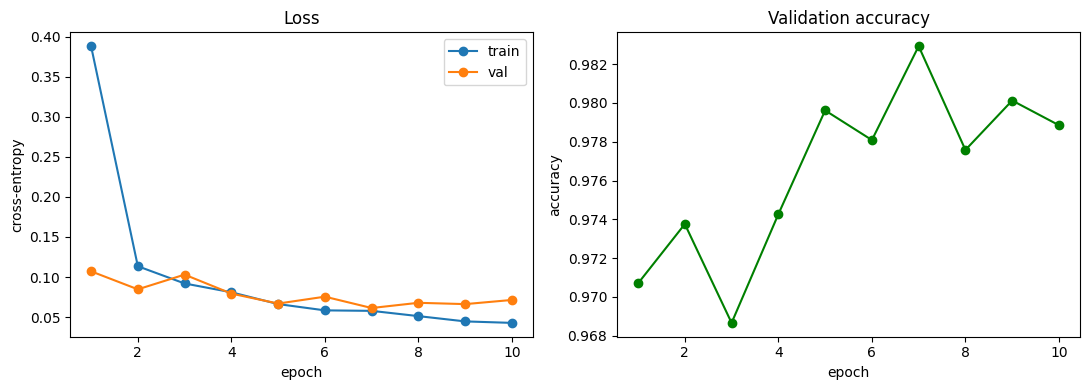

In [106]:
# Visualize the learning curves of the custom head.
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, history["train_loss"], marker="o", label="train")
plt.plot(epochs_ran, history["val_loss"], marker="o", label="val")
plt.title("Loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, history["val_acc"], marker="o", color="green")
plt.title("Validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")

plt.tight_layout()
plt.show()

## GradCAM

In [107]:
class GradCAM:

    def __init__(
        self,
        model: nn.Module,
        target_layer: nn.Module
    ) -> None:
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.__register_hooks()

    def __register_hooks(self):

        def forward_hook(module, input, output):
            print(f"Calling forward hook - activations shape: {output.shape}")
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            print(f"Calling backward hook - gradients shape: {grad_out[0].shape}")
            self.gradients = grad_out[0].detach()
    
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    

    def __call__(
        self, x: torch.Tensor,
        class_idx: int = None
    ) -> np.array:
        
        logits = self.model(x)
        class_idx = torch.argmax(logits) if class_idx is None else class_idx
        print(f"Class index is: {class_idx}")
        self.model.zero_grad()
        logits[:, class_idx].backward() # compute gradients w.r.t. the target class of the model / from user's input

        # [1, 512, 7, 7] -> [1, 512, 1, 1]
        print(f"> Gradients shape after backward: {self.gradients.shape if self.gradients is not None else 'None'}")
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        print(f"> Gradients shape after mean on col 2, 3: {weights.shape if weights is not None else 'None'}")

        # weights        -> [1, 512, 1, 1]
        # activations   -> [1, 512, 7, 7]
        # cam           -> [1,   1, 7, 7]
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        print(f"> First heatmap shape {cam.shape}")
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(512, 512), mode='bilinear', align_corners=False) # -> [1, 1, 224, 224]
        cam = cam.squeeze().cpu().numpy() # -> [22, 224]
        cam = (cam - cam.min()) / (cam.max() - cam.min()) # Normalization
        print(f"> Final heatmap shape {cam.shape}")
        return cam


In [115]:
def show_gradcam(image, cam):
    img_np = np.array(image.resize((224, 224)))
    cam = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlayed = heatmap + np.float32(img_np) / 255
    overlayed = overlayed / overlayed.max()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Map")
    plt.imshow(img_np)
    plt.axis('off')

    plt.subplot(1, 2 ,2)
    plt.title("Grad-CAM")
    plt.imshow(overlayed)
    plt.axis('off')
    
    plt.show()

In [125]:
idx = random.randint(0, len(val_dataset))
img, target, _, _ = val_dataset[idx]
gt_label = val_dataset.labels[idx]
image_path = val_dataset.images[idx]

# requires_grad_(True) lets gradients flow back to layer4 for Grad-CAM even
# though the backbone is frozen (only the input/activations carry grad now).
x = img.unsqueeze(0).to(device).requires_grad_(True)

In [126]:
gt_label, target

('speaker', 2)

Calling forward hook - activations shape: torch.Size([1, 512, 7, 7])
Calling forward hook - activations shape: torch.Size([1, 512, 7, 7])
Calling forward hook - activations shape: torch.Size([1, 512, 7, 7])
Calling forward hook - activations shape: torch.Size([1, 512, 7, 7])
Calling forward hook - activations shape: torch.Size([1, 512, 7, 7])
Calling forward hook - activations shape: torch.Size([1, 512, 7, 7])
Class index is: 2
Calling backward hook - gradients shape: torch.Size([1, 512, 7, 7])
Calling backward hook - gradients shape: torch.Size([1, 512, 7, 7])
Calling backward hook - gradients shape: torch.Size([1, 512, 7, 7])
Calling backward hook - gradients shape: torch.Size([1, 512, 7, 7])
Calling backward hook - gradients shape: torch.Size([1, 512, 7, 7])
Calling backward hook - gradients shape: torch.Size([1, 512, 7, 7])
> Gradients shape after backward: torch.Size([1, 512, 7, 7])
> Gradients shape after mean on col 2, 3: torch.Size([1, 512, 1, 1])
> First heatmap shape torch.Si

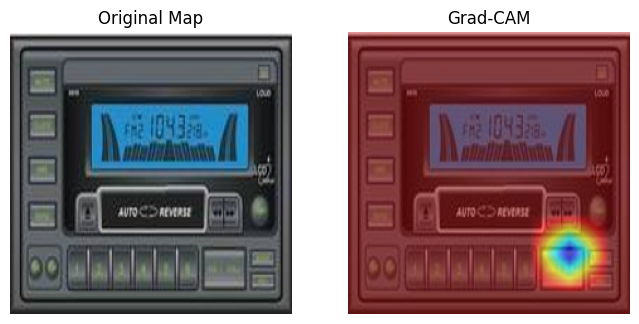

In [127]:
image = Image.open(image_path)

target_layer = model.layer4[-1].conv2

gradcam = GradCAM(model, target_layer)
cam = gradcam(x)
show_gradcam(image, cam)